1748992769.39487
Primeiras linhas de X após pré-processamento:
    PUERPERA  CARDIOPATI  HEMATOLOGI  SIND_DOWN  HEPATICA  ASMA  DIABETES  \
9        2.0         2.0         2.0        2.0       2.0   2.0       1.0   
10       2.0         1.0         2.0        2.0       2.0   2.0       2.0   
12       2.0         2.0         2.0        2.0       2.0   2.0       2.0   
14       2.0         2.0         2.0        2.0       2.0   2.0       2.0   
15       2.0         1.0         2.0        2.0       2.0   2.0       1.0   

    NEUROLOGIC  PNEUMOPATI  IMUNODEPRE  RENAL  OBESIDADE  OUT_MORBI  \
9          2.0         2.0         2.0    2.0        2.0        2.0   
10         2.0         2.0         2.0    2.0        2.0        1.0   
12         2.0         2.0         1.0    2.0        2.0        1.0   
14         2.0         1.0         2.0    2.0        2.0        2.0   
15         1.0         2.0         2.0    1.0        2.0        2.0   

    NU_IDADE_N CS_SEXO  SUPORT_VEN  UTI  
9    

/home/desmistificando-tb/notebook/lib64/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Melhores parâmetros encontrados: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}
Melhor F1-Score (macro) na validação cruzada: 0.8823

--- Avaliação do Melhor Modelo Random Forest ---
📊 Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.89      0.89     14113
         1.0       0.89      0.88      0.89     14112

    accuracy                           0.89     28225
   macro avg       0.89      0.89      0.89     28225
weighted avg       0.89      0.89      0.89     28225


Precisão para Óbito: 0.89
Recall para Óbito: 0.88
F1-Score para Óbito: 0.89

Matriz de Confusão:


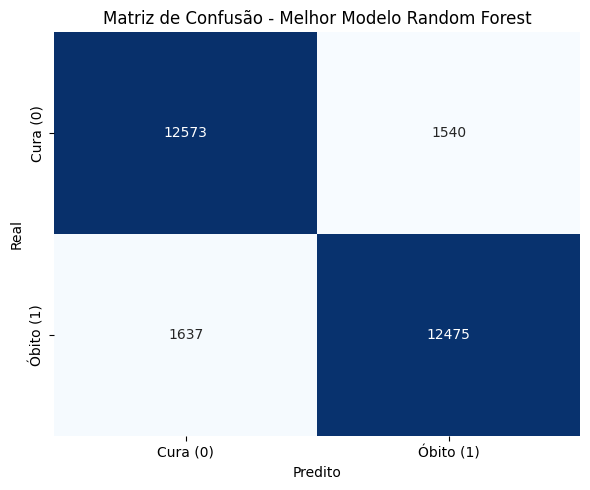

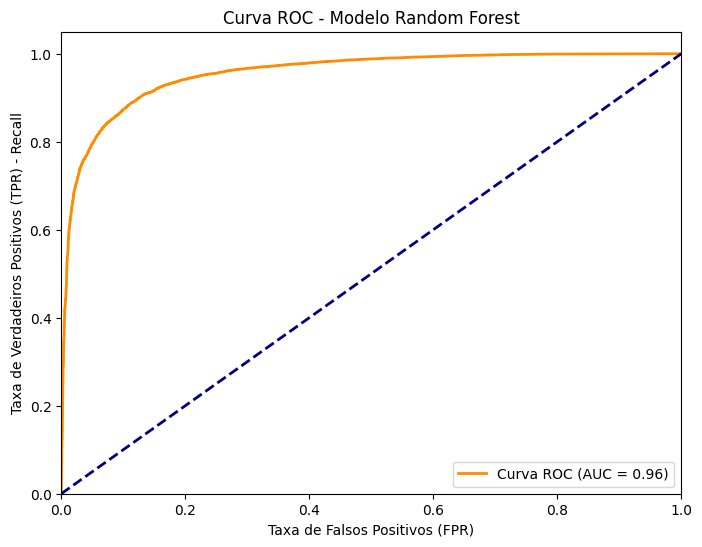


AUC do Modelo: 0.96


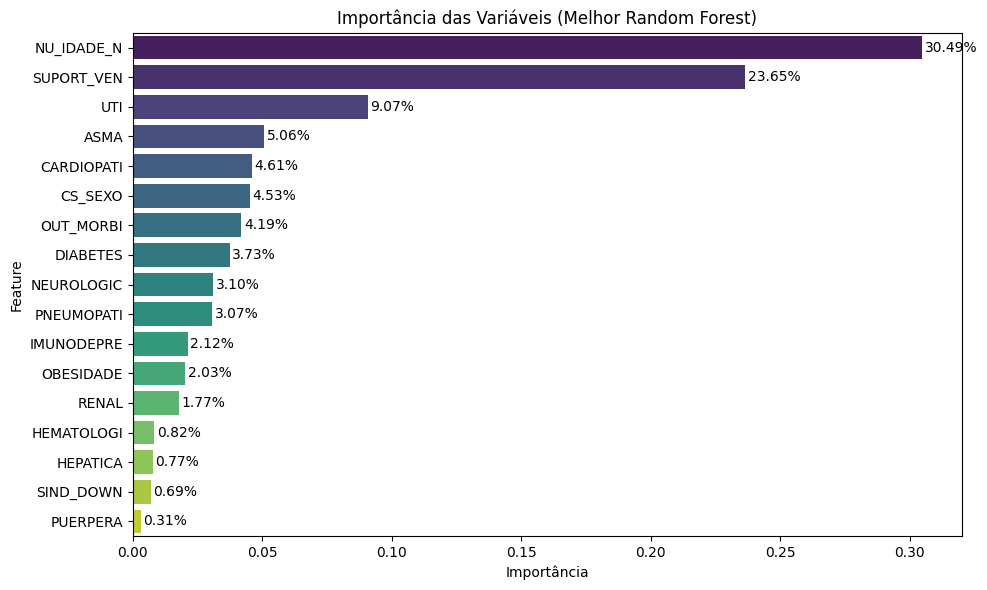


⏰ Tempo total de execução: 2272.29 segundos


In [4]:
# 📌 1. Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
# ⏰ Cronômetro
start_time = time.time()
print (start_time)

# 📌 2. Carregar os dados
df = pd.read_csv("./INFLUD24-03-02-2025.csv", sep=";", encoding="latin1", low_memory=False)

# 📌 3. Pré-processamento
df_filtered = df[df['EVOLUCAO'].isin([1, 2])].copy()
df_filtered.loc[:, 'EVOLUCAO'] = df_filtered['EVOLUCAO'].map({1: 0, 2: 1})

fatores_risco = [
    'PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA',
    'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE',
    'RENAL', 'OBESIDADE', 'OUT_MORBI'
]

# Convertendo para numérico
df_filtered.loc[:, fatores_risco] = df_filtered[fatores_risco].apply(pd.to_numeric, errors='coerce')
df_filtered.loc[:, 'NU_IDADE_N'] = pd.to_numeric(df_filtered['NU_IDADE_N'], errors='coerce')
df_filtered.loc[:, 'CS_SEXO'] = df_filtered['CS_SEXO'].map({'M': 0, 'F': 1})

# ➕ Convertendo SUPORT_VEN e UTI para numérico
df_filtered.loc[:, 'SUPORT_VEN'] = pd.to_numeric(df_filtered['SUPORT_VEN'], errors='coerce')
df_filtered.loc[:, 'UTI'] = pd.to_numeric(df_filtered['UTI'], errors='coerce')

# ➕ Atualizando colunas essenciais
colunas_essenciais = fatores_risco + ['EVOLUCAO', 'NU_IDADE_N', 'CS_SEXO', 'SUPORT_VEN', 'UTI']
df_filtered.dropna(subset=colunas_essenciais, inplace=True)

# ➕ Atualizando X
X = df_filtered[fatores_risco + ['NU_IDADE_N', 'CS_SEXO', 'SUPORT_VEN', 'UTI']]
y = df_filtered['EVOLUCAO']

print("Primeiras linhas de X após pré-processamento:")
print(X.head())
print("\nDistribuição de y após pré-processamento:")
print(y.value_counts())

# 📌 4. Balanceamento
print(f"Balanceamento antes: \n{y.value_counts()}")
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)
print(f"Balanceamento depois: \n{y_res.value_counts()}")

# 📌 5. Treinamento e Otimização com RandomForest
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.3, random_state=42, stratify=y_res
)

clf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=clf, param_grid=param_grid, cv=cv,
    scoring='f1_macro', n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nMelhores parâmetros encontrados: {grid_search.best_params_}")
print(f"Melhor F1-Score (macro) na validação cruzada: {grid_search.best_score_:.4f}")

best_clf = grid_search.best_estimator_

# 📌 6. Avaliação
y_pred = best_clf.predict(X_test)
y_prob = best_clf.predict_proba(X_test)[:, 1]

print("\n--- Avaliação do Melhor Modelo Random Forest ---")
print("📊 Classification Report:\n", classification_report(y_test, y_pred))

precision_óbitos = precision_score(y_test, y_pred, pos_label=1)
recall_óbitos = recall_score(y_test, y_pred, pos_label=1)
f1_óbitos = f1_score(y_test, y_pred, pos_label=1)

print(f"\nPrecisão para Óbito: {precision_óbitos:.2f}")
print(f"Recall para Óbito: {recall_óbitos:.2f}")
print(f"F1-Score para Óbito: {f1_óbitos:.2f}")

print("\nMatriz de Confusão:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Cura (0)', 'Óbito (1)'],
            yticklabels=['Cura (0)', 'Óbito (1)'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Melhor Modelo Random Forest')
plt.tight_layout()
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR) - Recall')
plt.title('Curva ROC - Modelo Random Forest')
plt.legend(loc="lower right")
plt.show()
print(f"\nAUC do Modelo: {roc_auc:.2f}")

# 📌 7. Importância das Features
importancias = pd.DataFrame({
    'Feature': X.columns,
    'Importância': best_clf.feature_importances_
}).sort_values(by='Importância', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importância', y='Feature', data=importancias, palette='viridis', hue='Feature', legend=False)
plt.title('Importância das Variáveis (Melhor Random Forest)')
for i, v in enumerate(importancias['Importância']):
    plt.text(v + 0.001, i, f"{v:.2%}", va='center')
plt.tight_layout()
plt.show()


# ⏰ Tempo total
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\n⏰ Tempo total de execução: {elapsed_time:.2f} segundos")